In [48]:
# Loaded variable 'df' from URI: /Users/user/Desktop/kkm1.csv
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [1]:
33473-2500

30973

In [855]:
import math
#generate some random data
def generate_points_on_circle(radius, num_points,noise):
    xpoints=[]
    ypoints=[]
    np.random.seed(37)
    for _ in range(num_points):
        # Generate a random angle in radians
       
        theta =np.random.uniform(0, 2 * math.pi)
        
        # Calculate x and y coordinates using polar coordinates
   
        x =  (radius+np.random.normal(0,noise,1)) * math.cos(theta)
      
        y =  (radius+np.random.normal(0,noise,1)) * math.sin(theta)
        
        xpoints.append(x)
        ypoints.append(y)
    
    return np.array(xpoints), np.array(ypoints)
#Parameteers
categories=3
factor=25
radius=[1,4,6]
noise=.5
#Contruct X(:,0) annd X(:,1)
Xp=np.empty((0,1))
Yp=np.empty((0,1))

for c in range(categories):
    num_points=factor*radius[c]
    xpoints,ypoints = generate_points_on_circle(radius[c], int(num_points),noise)
    Xp=np.vstack((Xp,xpoints))
    Yp=np.vstack((Yp,ypoints))

X=np.hstack((Xp,Yp))

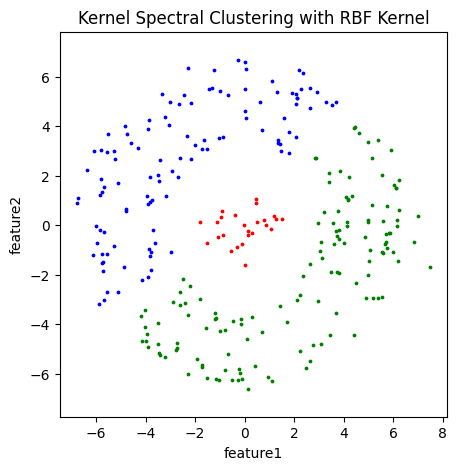

In [857]:
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=3, affinity='rbf', gamma=10,random_state=0).fit(X)

# Visualize the results
plt.figure(figsize=(5, 5))
colors = ['r','g','b']
for i in range(categories):
    plt.scatter(X[np.where(clustering.labels_==i),0],X[np.where(clustering.labels_==i),1], color=colors[i],s=3)
plt.title('Kernel Spectral Clustering with RBF Kernel')
plt.axis('equal')
plt.xlabel('feature1')
plt.ylabel('feature2')
plt.show()

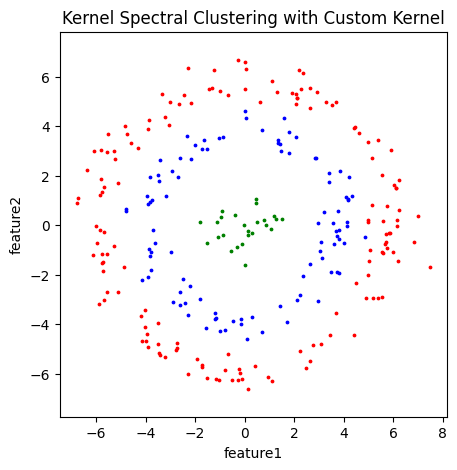

In [858]:
from sklearn.metrics.pairwise import pairwise_kernels
from sklearn.cluster import SpectralClustering
def custom_kernel(x,y,gamma=.5):
    return math.exp(-gamma*np.abs(np.linalg.norm(x)-np.linalg.norm(y)))
affinity_matrix = pairwise_kernels(X,X, metric=custom_kernel)
clustering = SpectralClustering(n_clusters=3,affinity='precomputed')
labels = clustering.fit_predict(affinity_matrix)


# Visualize the results
plt.figure(figsize=(5, 5))
colors = ['r','g','b']
for i in range(categories):
    plt.scatter(X[np.where(labels==i),0],X[np.where(labels==i),1], color=colors[i],s=3)
plt.title('Kernel Spectral Clustering with Custom Kernel')
plt.axis('equal')
plt.xlabel('feature1')
plt.ylabel('feature2')
plt.show()

In [185]:
eigvalues,eigenvectors=np.linalg.eigh(affinity_matrix)
np.any(eigvalues<0)

False

In [ ]:
import math as m
import numpy as np
#generate some random data
def generate_points_on_circle(angles, num_points,noise):
    xpoints=[]
    ypoints=[]
    np.random.seed(37)
    for _ in range(num_points):
        # Generate a random angle in radians
        randi =np.random.randint(0,3)
        
        # Calculate x and y coordinates using polar coordinates
   
        x =  np.sqrt(np.random.uniform(0,10)) * np.cos(angles[randi])+np.random.normal(0,noise)
      
        y =  np.sqrt(np.random.uniform(0,10)) * np.sin(angles[randi])+np.random.normal(0,noise)
        
        xpoints.append(x)
        ypoints.append(y)
    
    return np.array(xpoints), np.array(ypoints)
#Parameteers
num_points=100
angles=[0,2*m.pi/3,4*m.pi/3]
noise=.5

xpoints,ypoints = generate_points_on_circle(angles,num_points,noise)
    

X=(np.vstack((xpoints,ypoints))).T

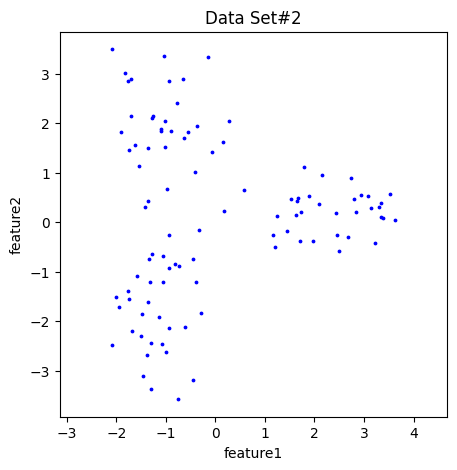

In [860]:
# Visualize the results
plt.figure(figsize=(5, 5))
plt.scatter(X[:,0],X[:,1], color='b',s=3)
plt.title('Data Set#2')
plt.axis('equal')
plt.xlabel('feature1')
plt.ylabel('feature2')
plt.show()

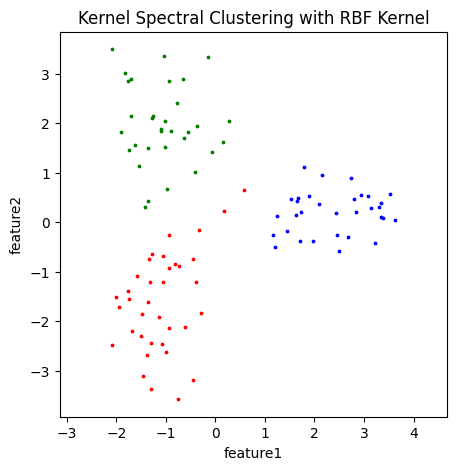

In [5]:
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=3, affinity='rbf', gamma=10,random_state=0).fit(X)

# Visualize the results
plt.figure(figsize=(5, 5))
colors = ['r','g','b']
categories=3
for i in range(categories):
    plt.scatter(X[np.where(clustering.labels_==i),0],X[np.where(clustering.labels_==i),1], color=colors[i],s=3)
plt.title('Kernel Spectral Clustering with RBF Kernel')
plt.axis('equal')
plt.xlabel('feature1')
plt.ylabel('feature2')
plt.show()

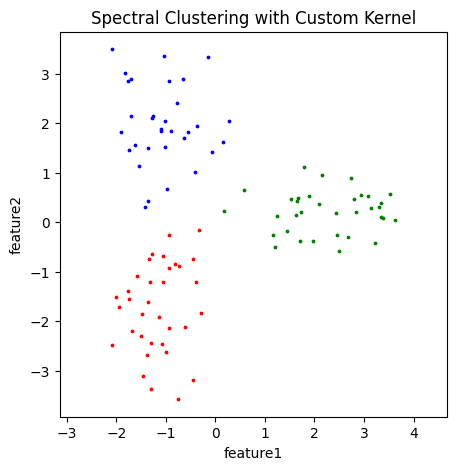

In [862]:
from sklearn.metrics.pairwise import pairwise_kernels
from sklearn.cluster import SpectralClustering
def custom_kernel(x,y,gamma=.1):
    return np.abs(np.cos(gamma*np.linalg.norm(x-y)))
    #return np.abs(np.cos(gamma*(np.arctan(x[1]/x[0])-np.arctan(y[1]/y[0]))))
epsilon=.1
affinity_matrix = pairwise_kernels(X,X, metric=custom_kernel)
clustering = SpectralClustering(n_clusters=3,affinity='precomputed')
labels = clustering.fit_predict(affinity_matrix)
5
# Visualize the results
plt.figure(figsize=(5, 5))
colors = ['r','g','b']
for i in range(categories):
    plt.scatter(X[np.where(labels==i),0],X[np.where(labels==i),1], color=colors[i],s=3)
plt.title('Spectral Clustering with Custom Kernel')
plt.axis('equal')
plt.xlabel('feature1')
plt.ylabel('feature2')
plt.show()

In [864]:
eigvalues,eigenvector=np.linalg.eigh(affinity_matrix)
np.any(eigvalues<0)

True

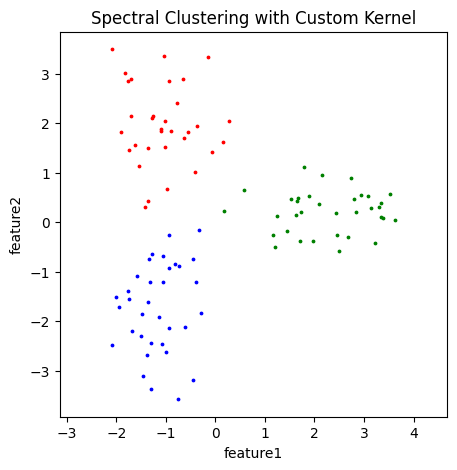

In [866]:
from sklearn.metrics.pairwise import pairwise_kernels
from sklearn.cluster import SpectralClustering
def custom_kernel(x,y,gamma=.1):
    return np.abs(np.cos(gamma*np.linalg.norm(x-y)))
    #return np.abs(np.cos(gamma*(np.arctan(x[1]/x[0])-np.arctan(y[1]/y[0]))))
epsilon=.2
affinity_matrix = pairwise_kernels(X,X, metric=custom_kernel)+epsilon*np.identity(np.shape(X)[0])
clustering = SpectralClustering(n_clusters=3,affinity='precomputed')
labels = clustering.fit_predict(affinity_matrix)
5
# Visualize the results
plt.figure(figsize=(5, 5))
colors = ['r','g','b']
for i in range(categories):
    plt.scatter(X[np.where(labels==i),0],X[np.where(labels==i),1], color=colors[i],s=3)
plt.title('Spectral Clustering with Custom Kernel')
plt.axis('equal')
plt.xlabel('feature1')
plt.ylabel('feature2')
plt.show()

In [886]:
eigvalues,eigenvector=np.linalg.eigh(affinity_matrix)
np.any(eigvalues<0)

False

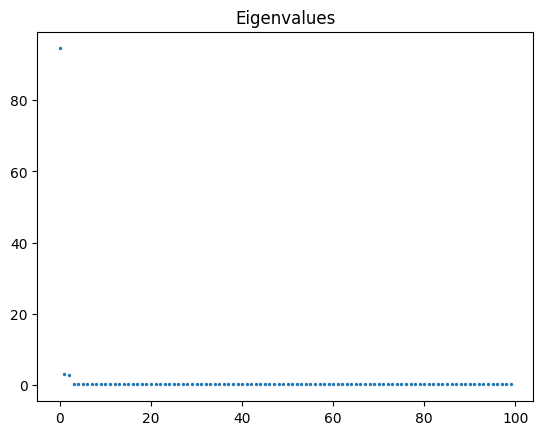

In [888]:
plt.title('Eigenvalues')
eigsort=np.sort(eigvalues)[::-1]
plt.scatter(range(len(eigsort)),eigsort,s=2)


In [68]:
import math as m
import numpy as np
#generate some random data
def generate_points_on_circle(angles, num_points,noise):
    xpoints=[]
    ypoints=[]
    np.random.seed(37)
    for _ in range(num_points):
        # Generate a random angle in radians
        randi =np.random.randint(0,3)
        
        # Calculate x and y coordinates using polar coordinates
   
        x =  np.sqrt(np.random.uniform(0,10)) * np.cos(angles[randi])+np.random.normal(0,noise)
      
        y =  np.sqrt(np.random.uniform(0,10)) * np.sin(angles[randi])+np.random.normal(0,noise)
        
        xpoints.append(x)
        ypoints.append(y)
    
    return np.array(xpoints), np.array(ypoints)
#Parameteers
num_points=100
angles=[0,2*m.pi/3,4*m.pi/3]
noise=2

xpoints,ypoints = generate_points_on_circle(angles,num_points,noise)
    

X=(np.vstack((xpoints,ypoints))).T

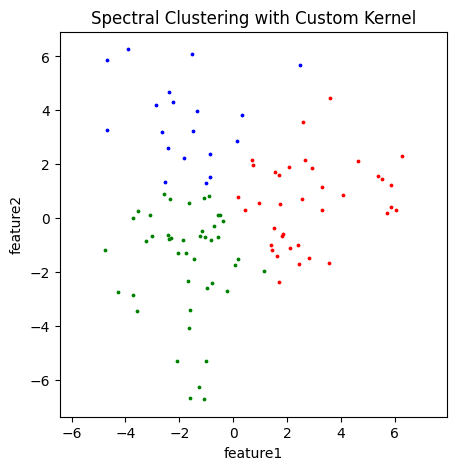

In [69]:
from sklearn.metrics.pairwise import pairwise_kernels
from sklearn.cluster import SpectralClustering
def custom_kernel(x,y,gamma=.1):
    return np.abs(np.cos(gamma*np.linalg.norm(x-y)))
    #return np.abs(np.cos(gamma*(np.arctan(x[1]/x[0])-np.arctan(y[1]/y[0]))))
epsilon=.2
affinity_matrix = pairwise_kernels(X,X, metric=custom_kernel)+epsilon*np.identity(np.shape(X)[0])
clustering = SpectralClustering(n_clusters=3,affinity='precomputed')
labels = clustering.fit_predict(affinity_matrix)
5
# Visualize the results
plt.figure(figsize=(5, 5))
colors = ['r','g','b']
for i in range(categories):
    plt.scatter(X[np.where(labels==i),0],X[np.where(labels==i),1], color=colors[i],s=3)
plt.title('Spectral Clustering with Custom Kernel')
plt.axis('equal')
plt.xlabel('feature1')
plt.ylabel('feature2')
plt.show()

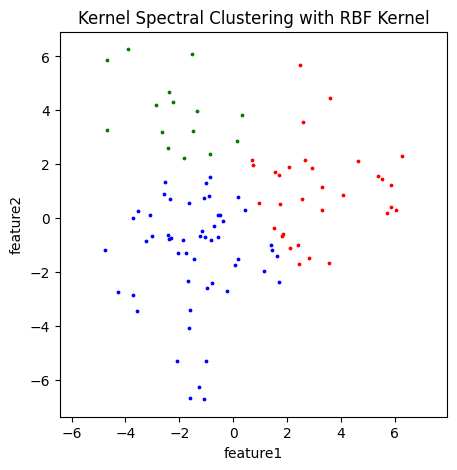

In [76]:
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=3, affinity='rbf', gamma=.05,random_state=0).fit(X)

# Visualize the results
plt.figure(figsize=(5, 5))
colors = ['r','g','b']
categories=3
for i in range(categories):
    plt.scatter(X[np.where(clustering.labels_==i),0],X[np.where(clustering.labels_==i),1], color=colors[i],s=3)
plt.title('Kernel Spectral Clustering with RBF Kernel')
plt.axis('equal')
plt.xlabel('feature1')
plt.ylabel('feature2')
plt.show()

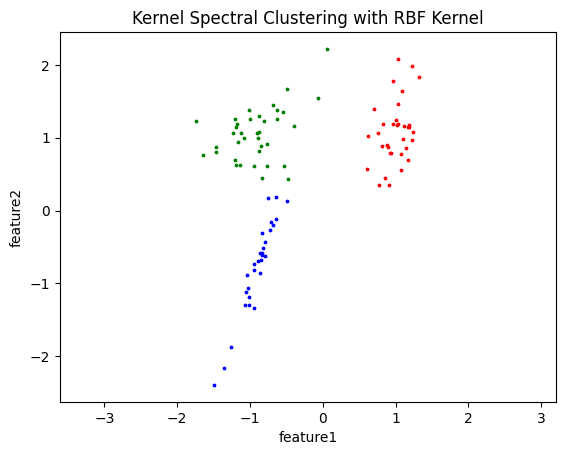

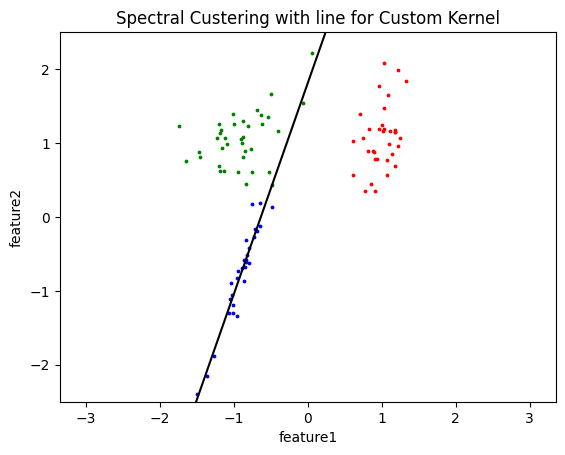

In [11]:
from sklearn.datasets import make_classification
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering
from matplotlib import pyplot as plt
import numpy as np
X, Y = make_classification(n_features=2, n_redundant=0, random_state=1,\
                           n_informative=2,n_clusters_per_class=1,n_classes=3)
categories=3
clustering = SpectralClustering(n_clusters=3, affinity='rbf', gamma=10,random_state=0).fit(X)

# Visualize the results
  
colors = ['r','g','b']
for i in range(categories):
    plt.scatter(X[np.where(clustering.labels_==i),0],X[np.where(clustering.labels_==i),1], color=colors[i],s=3)
plt.title('Kernel Spectral Clustering with RBF Kernel')
plt.axis('equal')
plt.xlabel('feature1')
plt.ylabel('feature2')
plt.show()
colors=['r','g','b']
#custom_cmap = LinearSegmentedColormap.from_list('cmap', colors, N=len(Y))
#plt.scatter(X[:, 0], X[:, 1],s=2,c=Y, cmap=custom_cmap)

# Fit the model to the data
index=np.where(clustering.labels_==2)[0] 
Xprime=np.hstack((X[index,0].reshape(-1,1),np.ones((len(index),1))))
#mean=X.mean(axis=0)
#from sklearn.decomposition import PCA
#pca = PCA(n_components=2)
#X_scaled = StandardScaler().fit_transform(X)
#pca.fit(X_scaled)
#slopePCA=(pca.components_[0,1]/pca.components_[0,0])
slope=np.linalg.pinv(Xprime)@X[index,1]
x=np.linspace(-2,.5,100)
plt.plot(x,slope[0]*x+slope[1],c='k')
#plt.plot(x,slopePCA*x+mean[1]-slopePCA*mean[0])
#plt.scatter(mean[0],mean[1],c='orange',s=15,marker='x')
for i in range(categories):
    plt.scatter(X[np.where(clustering.labels_==i),0],X[np.where(clustering.labels_==i),1], color=colors[i],s=3)
plt.title('Spectral Custering with line for Custom Kernel')
plt.axis('equal')
plt.ylim(-2.5,2.5)
plt.xlim(-2.5,2.5)
plt.xlabel('feature1')
plt.ylabel('feature2')
plt.show()


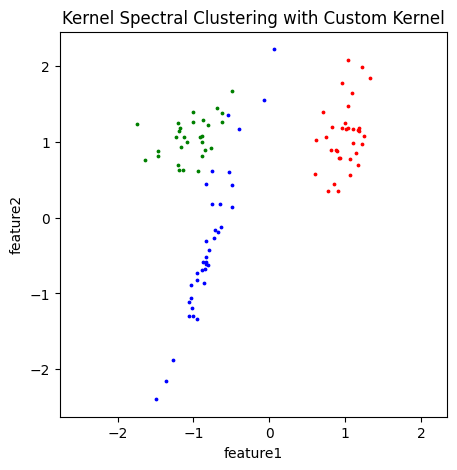

In [ ]:
from sklearn.metrics.pairwise import pairwise_kernels
from sklearn.cluster import SpectralClustering
def custom_kernel(x,y,m=slope[0],gamma=.5):
    return math.exp(-gamma*abs(m*x[0]-x[1]-m*y[0]+y[1])*(1+m**2)**(-1/2))
affinity_matrix = pairwise_kernels(X,X, metric=custom_kernel)
clustering = SpectralClustering(n_clusters=3,affinity='precomputed')
labels = clustering.fit_predict(affinity_matrix)


# Visualize the results
plt.figure(figsize=(5, 5))
colors = ['r','g','b']
for i in range(categories):
    plt.scatter(X[np.where(labels==i),0],X[np.where(labels==i),1], color=colors[i],s=3)
plt.title('Kernel Spectral Clustering with Custom Kernel')
plt.axis('equal')
plt.xlabel('feature1')
plt.ylabel('feature2')
plt.show()

In [923]:
eigvalues,eigenvectors=np.linalg.eigh(affinity_matrix)
np.any(eigvalues<0)

False